# Test parameter recovery for a separate-process 3AFC linear ballistic accumulator model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from devreact import model
from devreact import figures

%matplotlib inline
figures.set_style()

## Generate data

In [2]:
rng = np.random.default_rng()
nt = 1000
n = np.repeat([1, 2], int(nt / 2))
s = 1
τ = 0.5
A = 4
b = 5
v1 = 2.5
v2 = 3.5
v3 = 1.5
v4 = 2
data_mat = model.random_separate(n, s, τ, A, b, v1, v2, v3, v4, rng, size=(nt, 2))

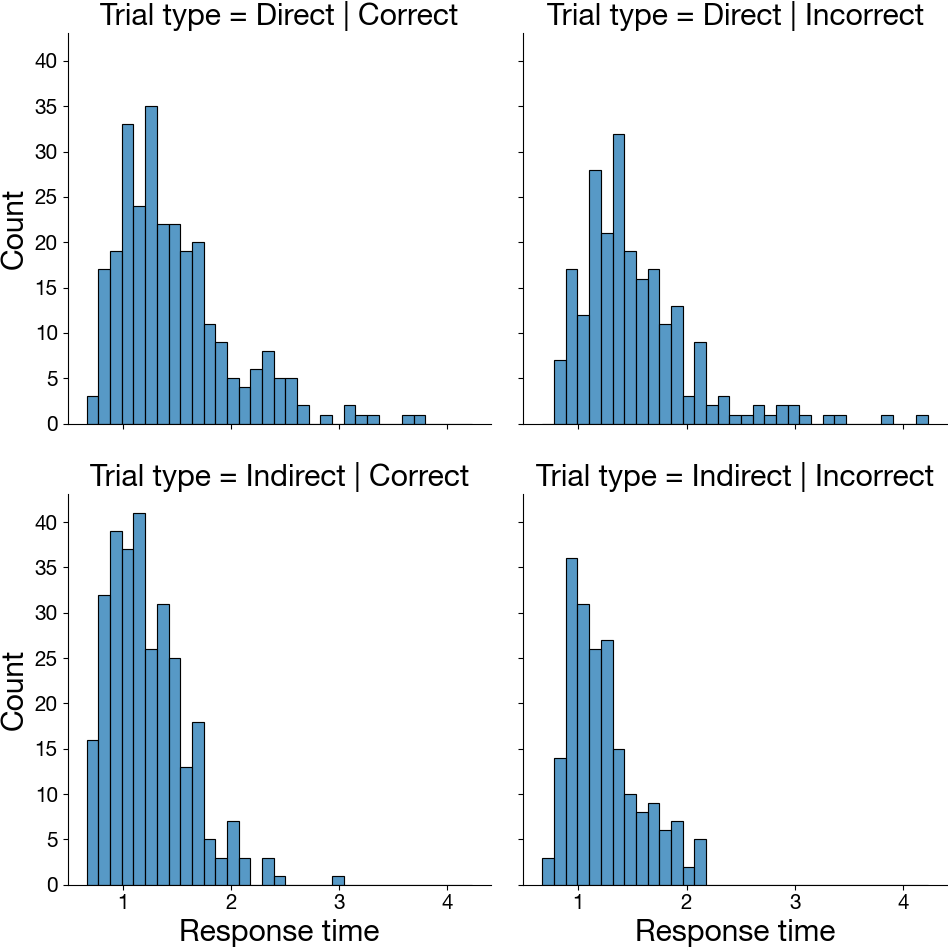

In [3]:
df = model.response_dataframe(data_mat, n)
g = sns.displot(
    data=df, 
    x='Response time', 
    col='Response', 
    col_order=['Correct', 'Incorrect'], 
    row='Trial type', 
    row_order=['Direct', 'Indirect'],
)
g.set_titles(col_template='{col_name}');

## Define probabilistic model

In [4]:
coords = {
    'component': ['response', 'response_time'], 
    'trial': np.arange(data_mat.shape[0]),
}
with pm.Model(coords=coords) as graph:
    x = pm.Data('x', data_mat, dims=['trial', 'component'])
    n_ = pm.Data('n', n, dims=['trial'])
    tind = pm.Data('trial_type_index', n - 1, dims=['trial'])
    
    τ_ = pm.Uniform("τ", lower=0, upper=1)
    A_ = pm.Uniform("A", lower=0, upper=10)
    b_ = pm.Uniform("b", lower=0, upper=10)
    v1_ = pm.Uniform("v1", lower=0, upper=5)
    v2_ = pm.Uniform("v2", lower=0, upper=5)
    v3_ = pm.Uniform("v3", lower=0, upper=5)
    v4_ = pm.Uniform("v4", lower=0, upper=5)
    
    response = pm.DensityDist(
        'response',
        n_,
        s, 
        τ_, 
        A_, 
        b_, 
        v1_, 
        v2_,
        v3_,
        v4_,
        logp=model.logp_separate,
        random=model.random_separate,
        observed=x,
        dims=['trial', 'component'],
    )

## Prior predictive samples

In [5]:
with graph:
    pp = pm.sample_prior_predictive()

Sampling: [A, b, response, v1, v2, v3, v4, τ]


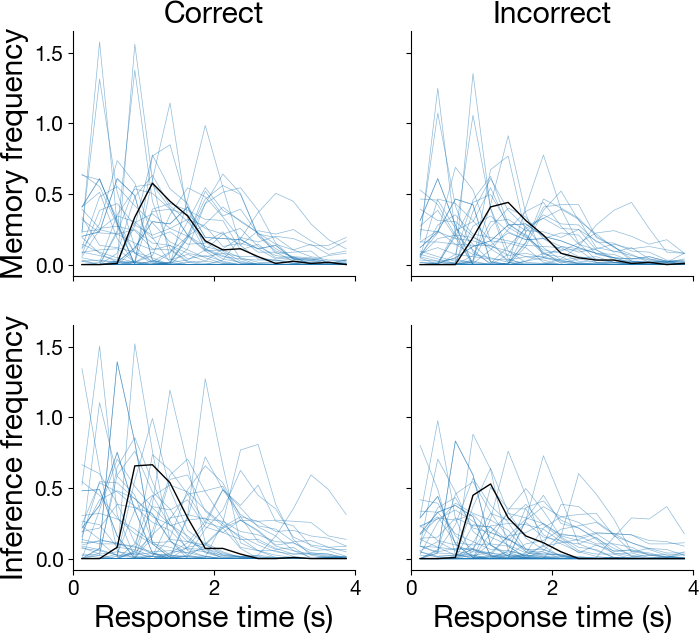

In [6]:
figures.plot_predictive(pp, group='prior', max_time=4);

## Sample posterior distribution

In [7]:
with graph:
    trace = pm.sample(tune=1000, target_accept=0.95)

 Progress                      Draw   Divergences   Step size   Grad evals   Speed           Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.026       63           49.92 draws/s   0:00:40   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.023       31           56.71 draws/s   0:00:35   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.030       63           52.73 draws/s   0:00:37   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.043       95           50.07 draws/s   0:00:39   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.


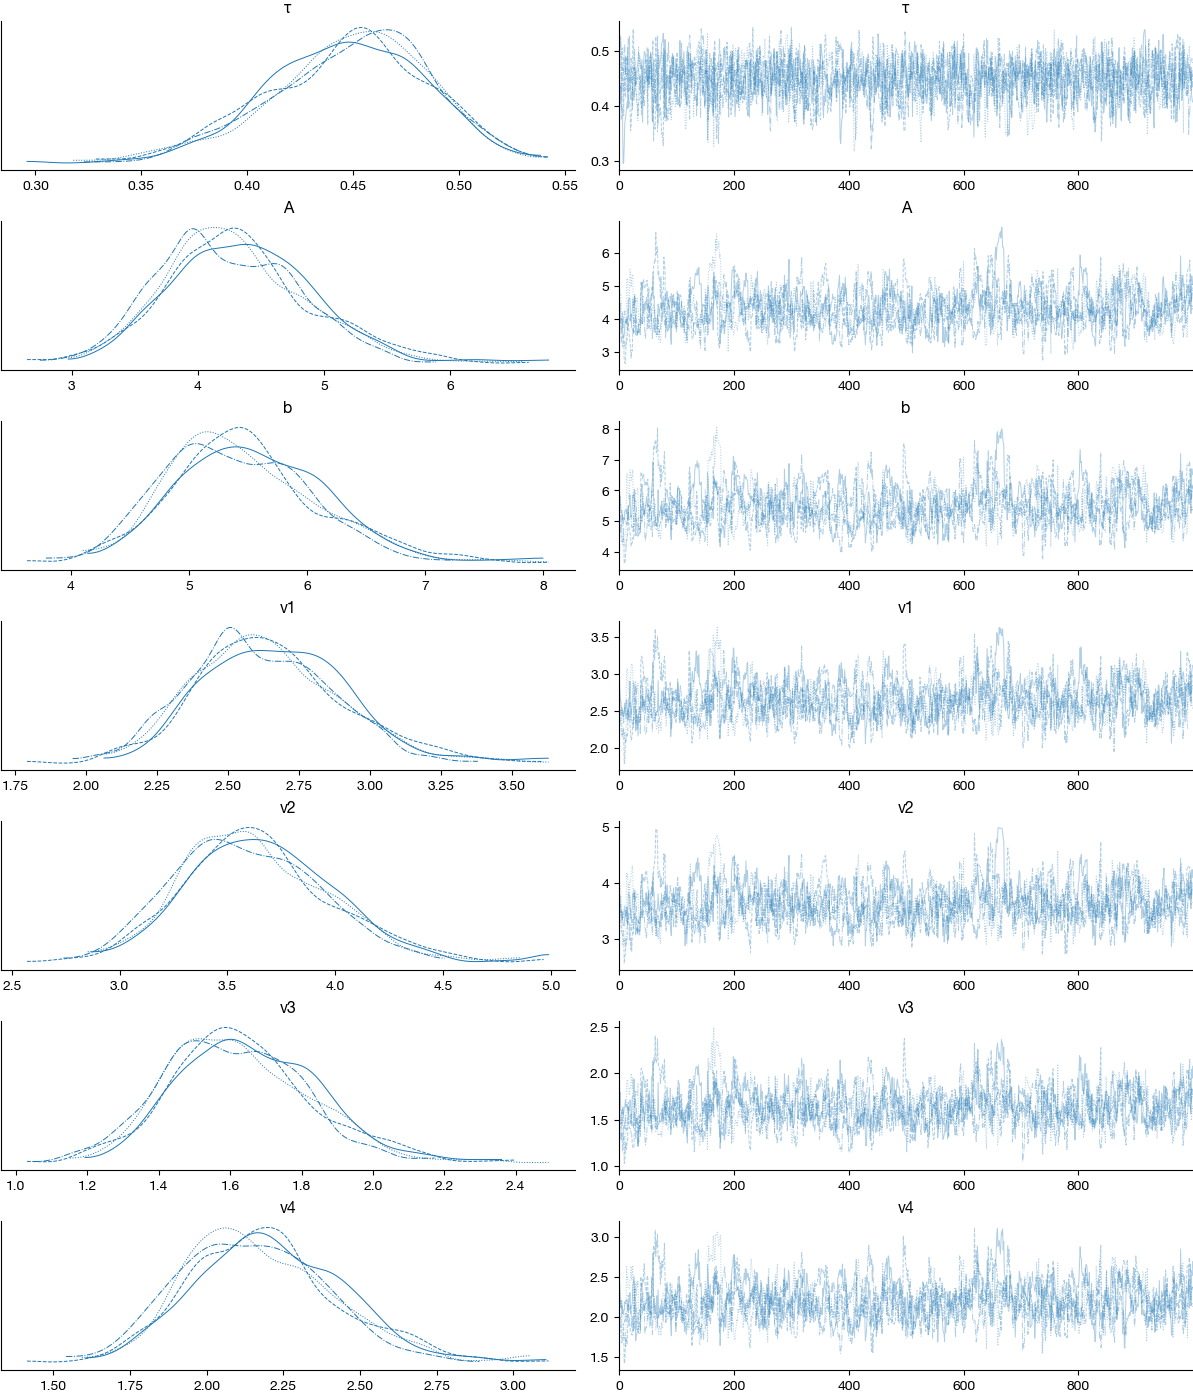

In [8]:
with mpl.rc_context({'figure.constrained_layout.use': True}):
    az.plot_trace(trace);

In [9]:
print(τ, A, b, v1, v2, v3, v4)

0.5 4 5 2.5 3.5 1.5 2


## Examine posterior predictive samples

In [10]:
with graph:
    pp = pm.sample_posterior_predictive(trace)

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

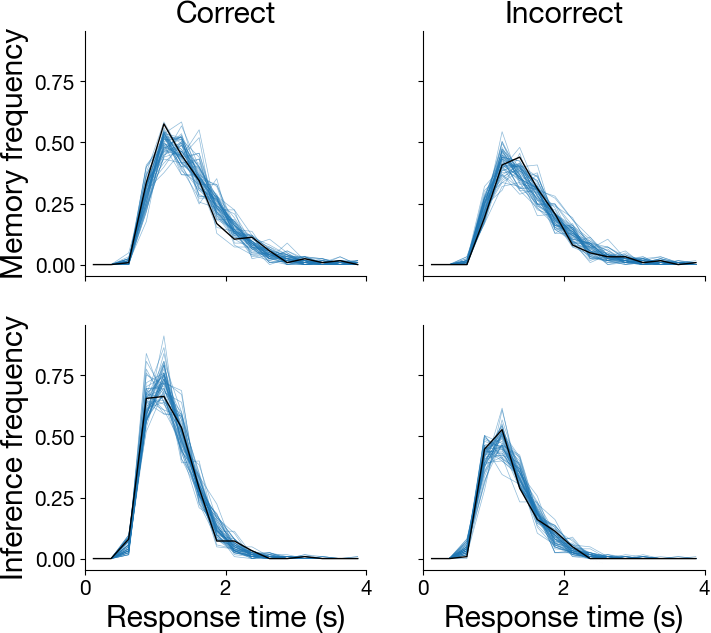

In [11]:
figures.plot_predictive(pp, group='posterior', max_time=4);

In [12]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.13.6
IPython version      : 9.12.0

arviz     : 0.23.4
devreact  : 0.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
pymc      : 5.28.3
seaborn   : 0.13.2

